In [ ]:
# Cell 1: Import necessary libraries and define basic utilities
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image
import math
import torch
import torchvision
from collections import namedtuple
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import torch.nn.functional as F
from collections import namedtuple
from torchvision import models
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassAccuracy, MulticlassDiceScore

In [9]:
# Cell 2: Define file paths for training and validation images and masks
train_images_folder_path = "../data/train/images" 
train_mask_folder_path = "../data/train/masks" 
test_images_folder_path = "../data/val/images" 
test_mask_folder_path = "../data/val/masks" 

In [10]:
# Cell 3: Load and sort image and mask filenames for training and validation sets
train_imgs = sorted([img for img in os.listdir(train_images_folder_path) if img.endswith('.png')])
train_msks = sorted([img for img in os.listdir(train_mask_folder_path) if img.endswith('.png')])
val_imgs = sorted([img for img in os.listdir(test_images_folder_path) if img.endswith('.png')])
val_msks = sorted([img for img in os.listdir(test_mask_folder_path) if img.endswith('.png')])

In [ ]:
# Cell 4: Set computation device and compute basic dataset statistics
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_mask_as_grayscale(mask_path):
    """Load a mask and ensure it's a 2D grayscale array."""
    img = Image.open(mask_path)
    if img.mode != 'L':
        img = img.convert('L')
    return np.array(img)

def collect_stats(img_dir, msk_dir, img_names, msk_names, label, sample_size=200):
    """Collect image dimensions and class frequencies."""
    heights, widths = [], []
    class_counter = {}
    sample_idx = np.random.choice(len(img_names), min(sample_size, len(img_names)), replace=False)
    for i in sample_idx:
        img = Image.open(os.path.join(img_dir, img_names[i]))
        msk = load_mask_as_grayscale(os.path.join(msk_dir, msk_names[i]))
        heights.append(img.height)
        widths.append(img.width)
        uniq, counts = np.unique(msk, return_counts=True)
        for u, c in zip(uniq, counts):
            class_counter[u] = class_counter.get(u, 0) + c
    return {
        'label': label,
        'count': len(img_names),
        'mean_h': np.mean(heights),
        'mean_w': np.mean(widths),
        'std_h': np.std(heights),
        'std_w': np.std(widths),
        'class_dist': class_counter
    }
train_stats = collect_stats(train_images_folder_path, train_mask_folder_path, train_imgs, train_msks, 'Train')
val_stats   = collect_stats(test_images_folder_path, test_mask_folder_path, val_imgs, val_msks, 'Validation')
dim_df = pd.DataFrame([train_stats, val_stats])[['label', 'count', 'mean_h', 'mean_w', 'std_h', 'std_w']]
dim_df.columns = ['Dataset', 'Samples', 'Mean Height', 'Mean Width', 'Height Std', 'Width Std']
print("📏 Image Dimension Summary")
display(dim_df.style.format({'Mean Height': '{:.1f}', 'Mean Width': '{:.1f}', 'Height Std': '{:.1f}', 'Width Std': '{:.1f}'}))

📏 Image Dimension Summary


,Dataset,Samples,Mean Height,Mean Width,Height Std,Width Std
0,Train,2975,96.0,256.0,0.0,0.0
1,Validation,480,96.0,256.0,0.0,0.0


/tmp/ipykernel_43683/3358478647.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_func = plt.cm.get_cmap(cmap)


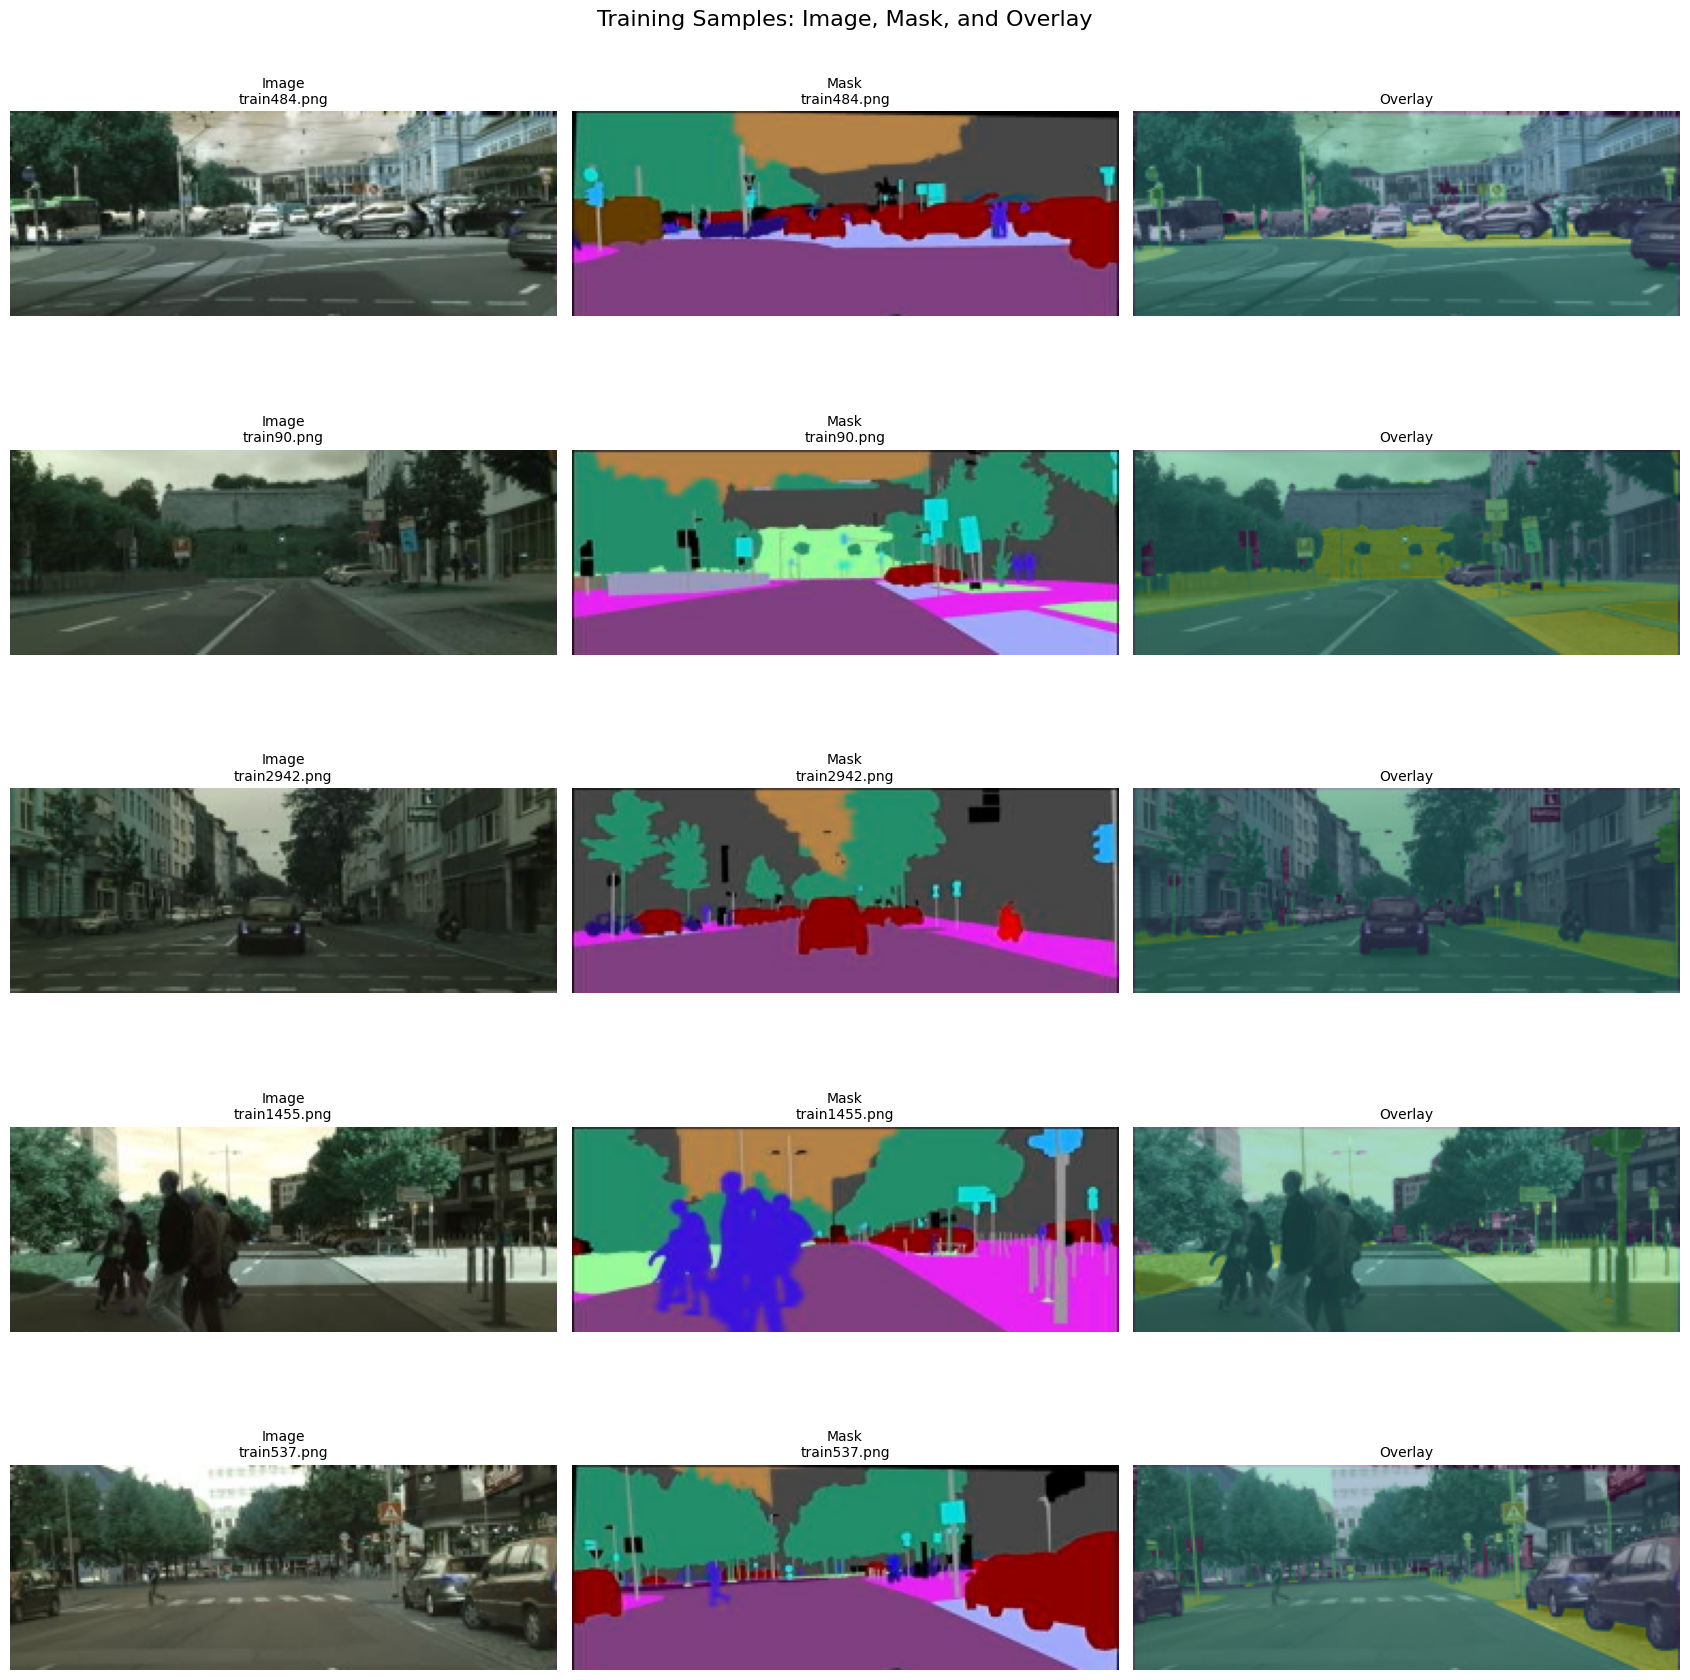

In [12]:
# Cell 5: Visualize sample training images, masks, and overlayed masks
def overlay_mask(image, mask, alpha=0.4, cmap='viridis'):
    if mask.ndim == 3:
        mask = mask.mean(axis=2).astype(np.uint8)
    mask_max = mask.max()
    mask_norm = mask.astype(float) / (mask_max if mask_max > 0 else 1)
    cmap_func = plt.cm.get_cmap(cmap)
    mask_colored = cmap_func(mask_norm)
    mask_colored_rgb = mask_colored[..., :3]
    image_norm = image.astype(float) / 255.0
    blended = (1 - alpha) * image_norm + alpha * mask_colored_rgb
    blended = np.clip(blended, 0, 1)
    return blended
np.random.seed(42)
indices = np.random.choice(len(train_imgs), 5, replace=False)
fig, axes = plt.subplots(5, 3, figsize=(17, 18))
for i, idx in enumerate(indices):
    img = np.array(Image.open(os.path.join(train_images_folder_path, train_imgs[idx])))
    msk = np.array(Image.open(os.path.join(train_mask_folder_path, train_msks[idx])))
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image\n{train_imgs[idx]}", fontsize=10)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(msk, cmap='viridis')
    axes[i, 1].set_title(f"Mask\n{train_msks[idx]}", fontsize=10)
    axes[i, 1].axis('off')
    axes[i, 2].imshow(overlay_mask(img, msk))
    axes[i, 2].set_title("Overlay", fontsize=10)
    axes[i, 2].axis('off')
plt.suptitle("Training Samples: Image, Mask, and Overlay", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [13]:
# Cell 6: Define segmentation labels, colors, and mask processing function
num_classes = 19
Label = namedtuple('Label', ['name', 'trainId', 'color'])
labels = [
    Label('road', 0, (128, 64, 128)), Label('sidewalk', 1, (244, 35, 232)), Label('building', 2, (70, 70, 70)),
    Label('wall', 3, (102, 102, 156)), Label('fence', 4, (190, 153, 153)), Label('pole', 5, (153, 153, 153)),
    Label('traffic light', 6, (250, 170, 30)), Label('traffic sign', 7, (220, 220, 0)), Label('vegetation', 8, (107, 142, 35)),
    Label('terrain', 9, (152, 251, 152)), Label('sky', 10, (70, 130, 180)), Label('person', 11, (220, 20, 60)),
    Label('rider', 12, (255, 0, 0)), Label('car', 13, (0, 0, 142)), Label('truck', 14, (0, 0, 70)),
    Label('bus', 15, (0, 60, 100)), Label('train', 16, (0, 80, 100)), Label('motorcycle', 17, (0, 0, 230)),
    Label('bicycle', 18, (119, 11, 32))
]
trainId2name = {l.trainId: l.name for l in labels}
valid_colors = np.array([l.color for l in labels])
valid_ids = np.array([l.trainId for l in labels])
def process_mask_to_train_id(mask_path, height=96, width=256):
    img = Image.open(mask_path).convert('RGB')
    img = img.resize((width, height), resample=Image.NEAREST)
    flat_mask = np.array(img).astype(np.int32).reshape(-1, 3)
    dists = np.sum((flat_mask[:, None, :] - valid_colors[None, :, :]) ** 2, axis=2)
    min_indices = np.argmin(dists, axis=1)
    min_dists = np.min(dists, axis=1)
    final_ids = valid_ids[min_indices]
    final_ids[min_dists > 50] = 255
    return final_ids.reshape(height, width)

In [14]:
# Cell 7: Analyze pixel distribution per class in a random subset of training masks
subset_size = min(300, len(train_msks))
indices = np.random.choice(len(train_msks), subset_size, replace=False)
pixel_counts = {name: 0 for name in trainId2name.values()}
size_data = {name: [] for name in trainId2name.values()}
for i in indices:
    mask_path = os.path.join(train_mask_folder_path, train_msks[i])
    mask_id = process_mask_to_train_id(mask_path)
    ids, counts = np.unique(mask_id, return_counts=True)
    for t_id, count in zip(ids, counts):
        if t_id in trainId2name:
            name = trainId2name[t_id]
            pixel_counts[name] += count
            size_data[name].append(count)

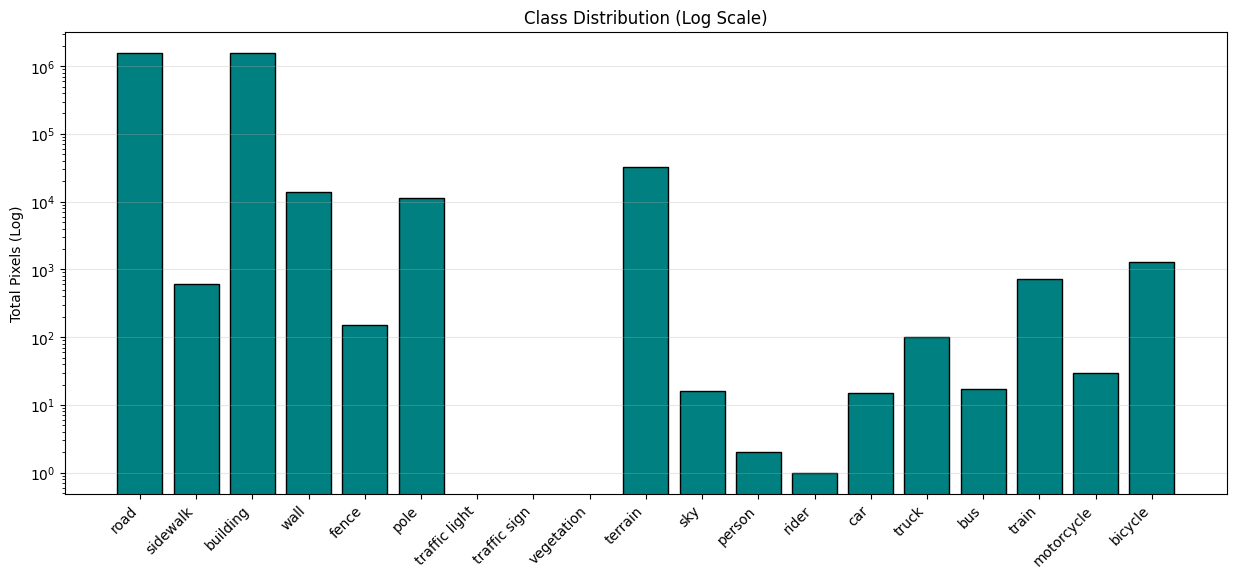

In [15]:
# Cell 8: Plot total pixel distribution per class (log scale)
plt.figure(figsize=(15, 6))
plt.bar(pixel_counts.keys(), pixel_counts.values(), color='teal', edgecolor='black', log=True)
plt.title('Class Distribution (Log Scale)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Pixels (Log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

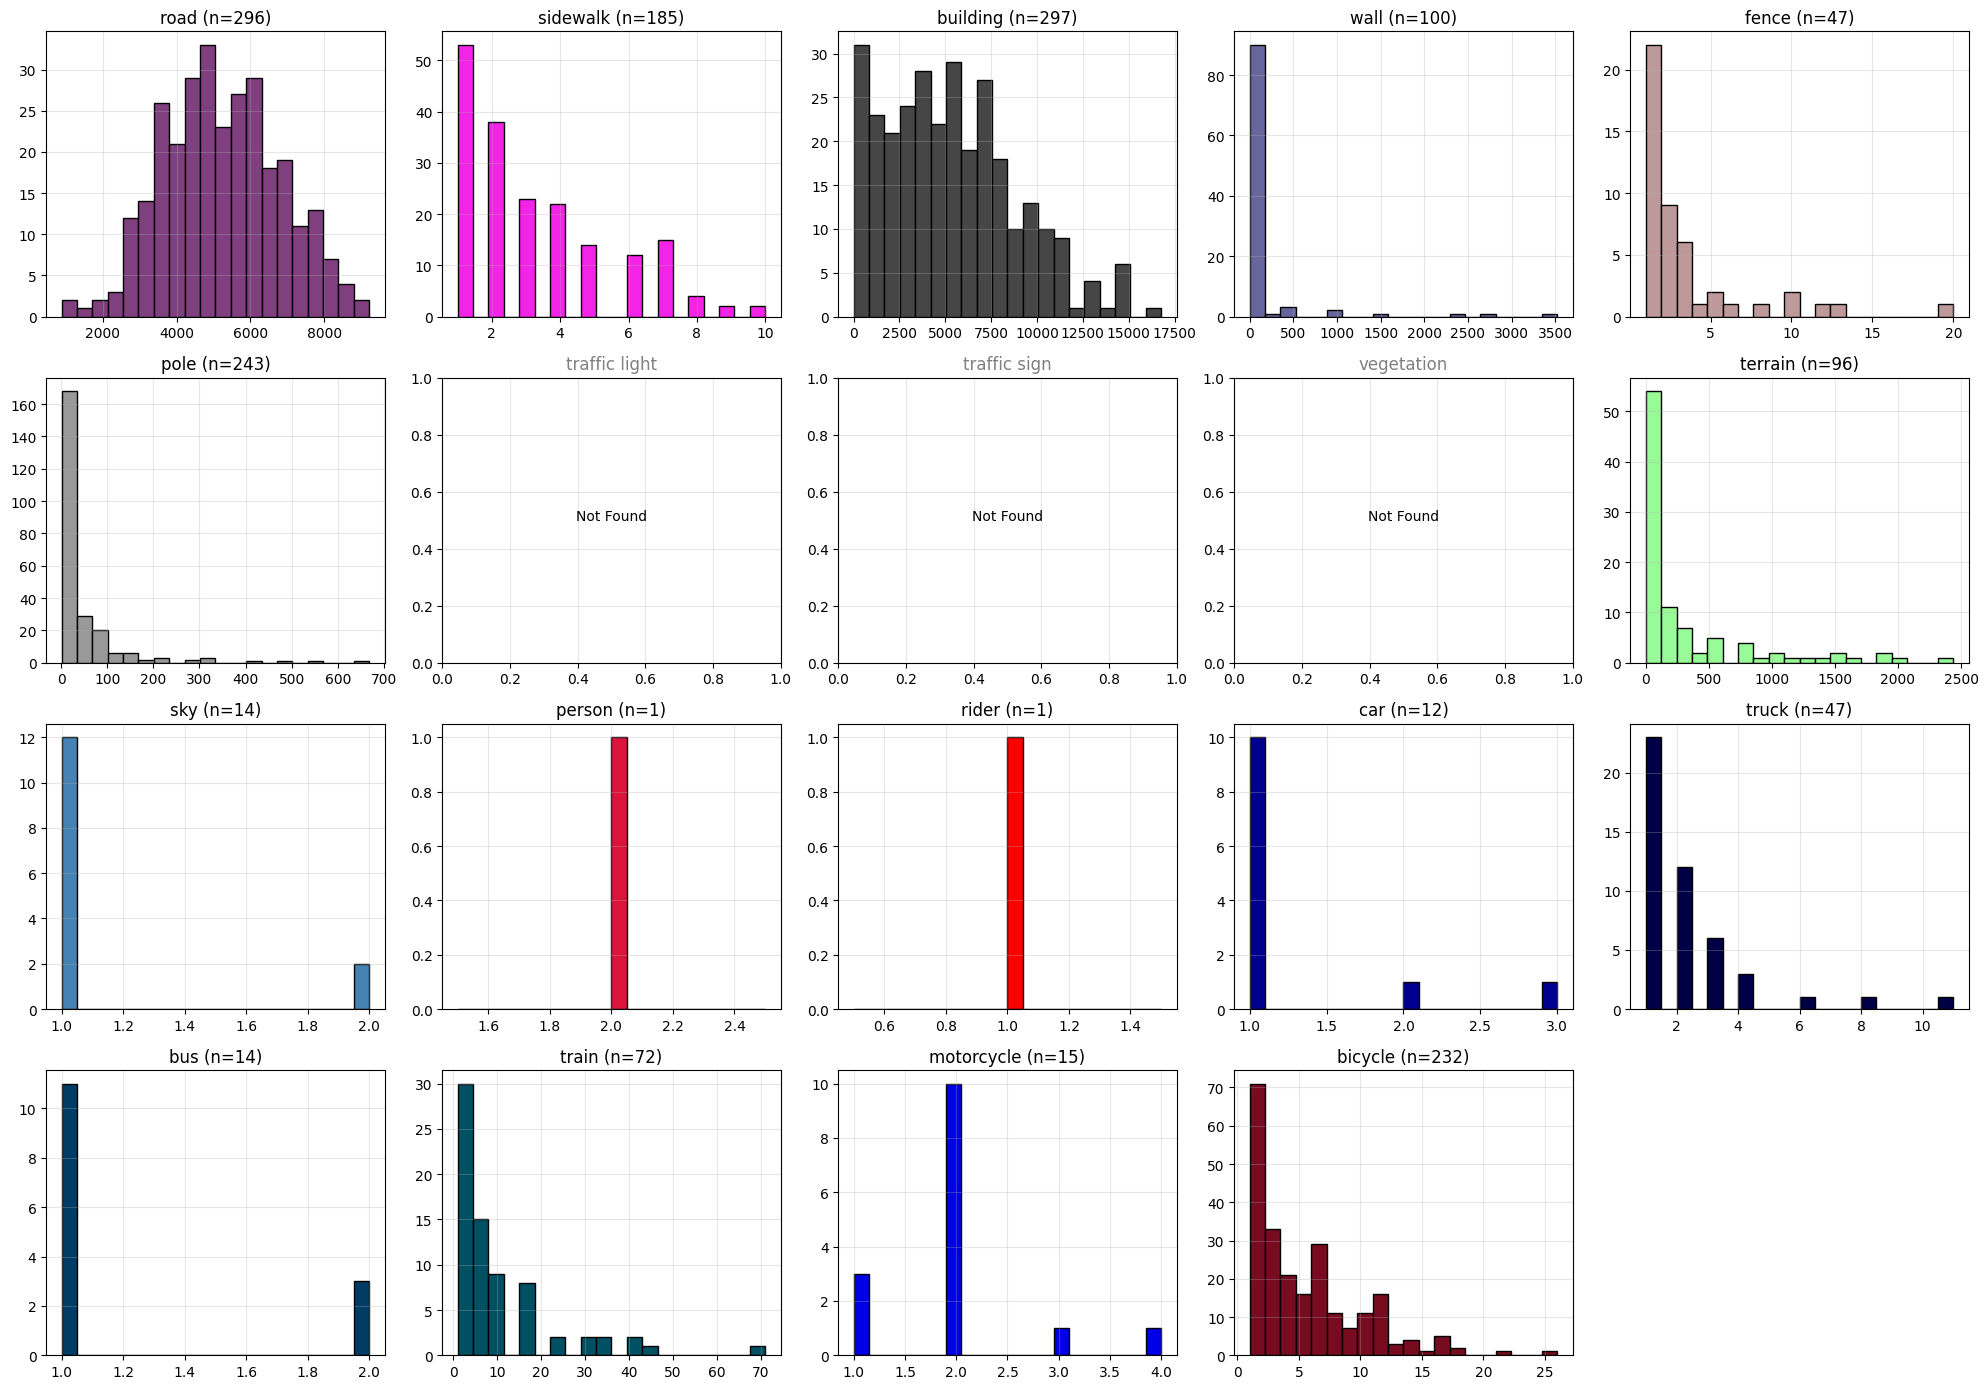

In [16]:
# Cell 9: Plot per-class pixel count distributions across sampled training masks
active_classes = list(trainId2name.values())
cols = 5
rows = (len(active_classes) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
axes = axes.flatten()
for i, name in enumerate(active_classes):
    ax = axes[i]
    data = size_data[name]
    color = np.array(next(l.color for l in labels if l.name == name)) / 255.0
    if data:
        ax.hist(data, bins=20, color=color, edgecolor='black')
        ax.set_title(f'{name} (n={len(data)})')
    else:
        ax.text(0.5, 0.5, 'Not Found', ha='center')
        ax.set_title(name, color='gray')
    ax.grid(alpha=0.3)
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

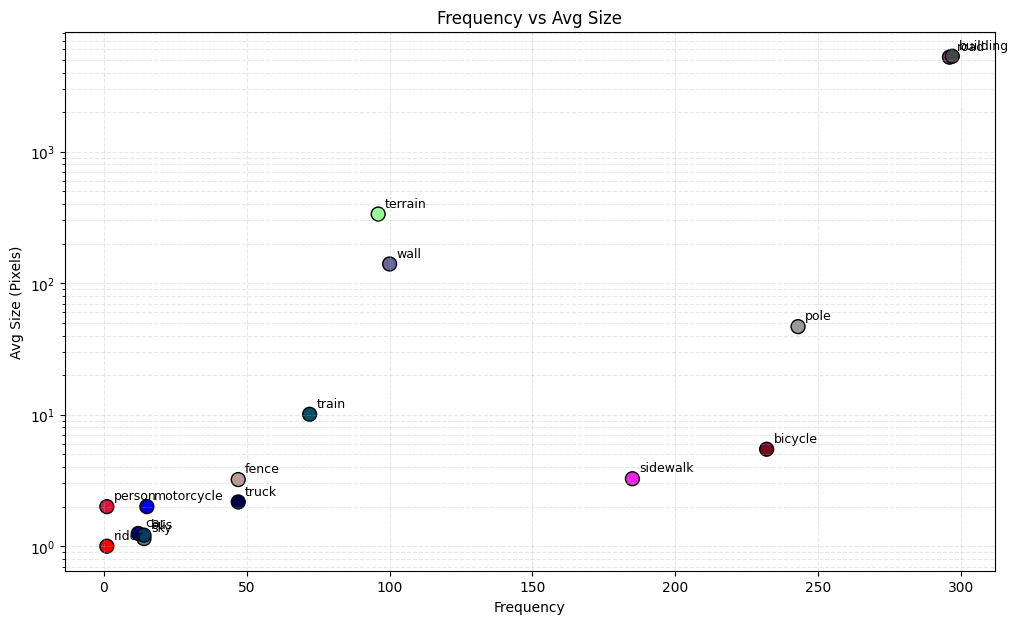

In [17]:
# Cell 10: Scatter plot of class frequency vs. average pixel size
freqs, sizes, colors, names = [], [], [], []
for name in active_classes:
    if size_data[name]:
        freqs.append(len(size_data[name]))
        sizes.append(np.mean(size_data[name]))
        colors.append(np.array(next(l.color for l in labels if l.name == name)) / 255.0)
        names.append(name)
plt.figure(figsize=(12, 7))
plt.scatter(freqs, sizes, s=100, c=colors, edgecolor='black')
for i, txt in enumerate(names):
    plt.annotate(txt, (freqs[i], sizes[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.yscale('log')
plt.title('Frequency vs Avg Size')
plt.xlabel('Frequency')
plt.ylabel('Avg Size (Pixels)')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

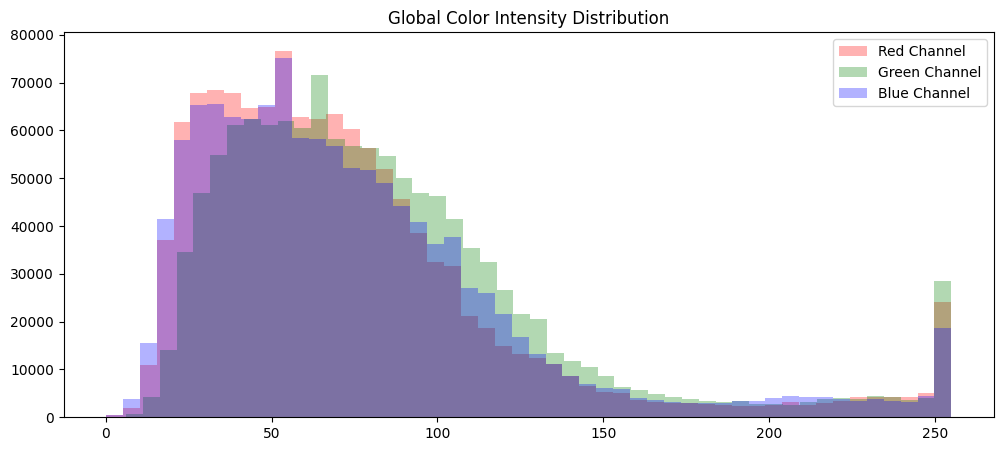

In [18]:
# Cell 11: Plot global RGB color intensity distribution for sampled training images
r, g, b = [], [], []
for i in indices[:50]:
    img_path = os.path.join(train_images_folder_path, train_imgs[i])
    img = np.array(Image.open(img_path).convert('RGB'))
    r.append(img[:,:,0].flatten())
    g.append(img[:,:,1].flatten())
    b.append(img[:,:,2].flatten())
plt.figure(figsize=(12, 5))
plt.hist(np.concatenate(r), bins=50, color='red', alpha=0.3, label='Red Channel')
plt.hist(np.concatenate(g), bins=50, color='green', alpha=0.3, label='Green Channel')
plt.hist(np.concatenate(b), bins=50, color='blue', alpha=0.3, label='Blue Channel')
plt.title('Global Color Intensity Distribution')
plt.legend()
plt.show()

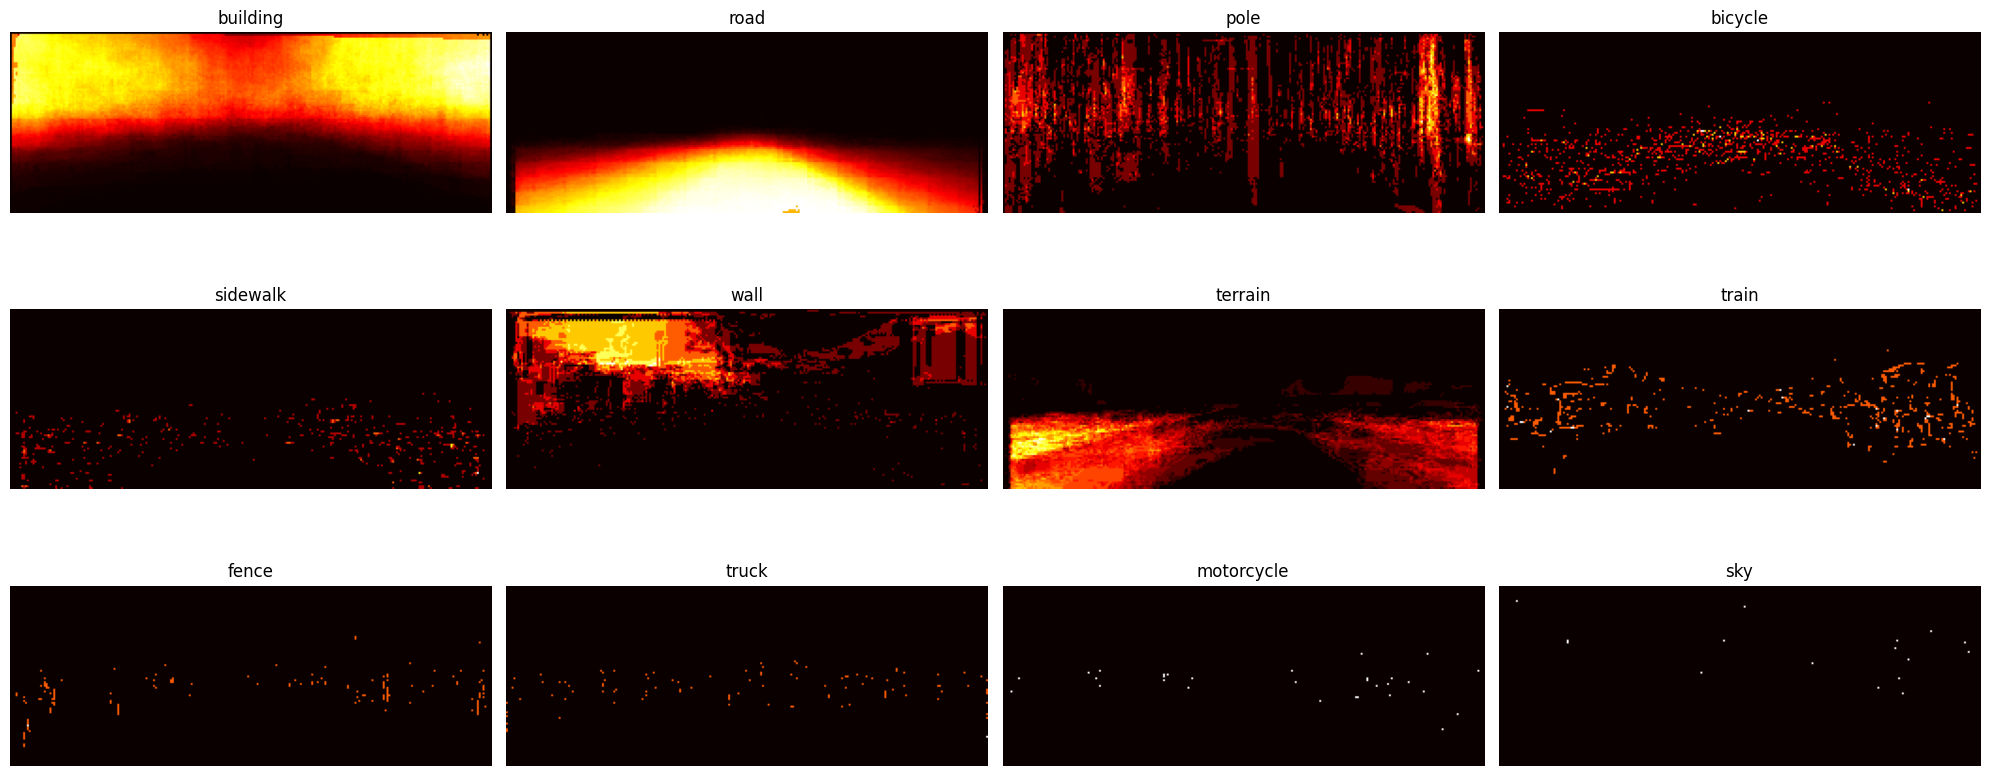

In [19]:
# Cell 12: Generate and display heatmaps for the top classes in training masks
top_classes = sorted(active_classes, key=lambda n: len(size_data[n]), reverse=True)[:12]
heatmaps = {n: np.zeros((96, 256)) for n in top_classes}
for i in indices:
    mask = process_mask_to_train_id(os.path.join(train_mask_folder_path, train_msks[i]))
    for name in top_classes:
        tid = next(l.trainId for l in labels if l.name == name)
        heatmaps[name] += (mask == tid).astype(float)
cols = 4
rows = (len(top_classes) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
axes = axes.flatten()
for i, name in enumerate(top_classes):
    axes[i].imshow(heatmaps[name], cmap='hot')
    axes[i].set_title(name)
    axes[i].axis('off')
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()

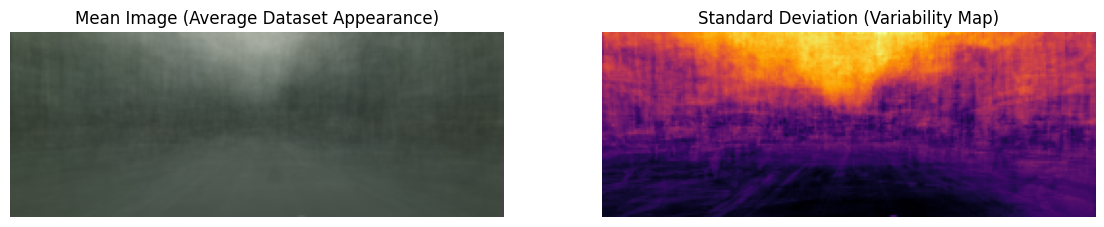

In [20]:
# Cell 13: Compute and display mean and standard deviation images for sampled training set
sum_img = np.zeros((96, 256, 3))
sq_sum_img = np.zeros((96, 256, 3))
count = 0
for i in indices[:100]:
    img_path = os.path.join(train_images_folder_path, train_imgs[i])
    img = Image.open(img_path).convert('RGB').resize((256, 96))
    arr = np.array(img) / 255.0
    sum_img += arr
    sq_sum_img += arr ** 2
    count += 1
mean_img = sum_img / count
std_img = np.sqrt((sq_sum_img / count) - (mean_img ** 2))
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(mean_img)
plt.title('Mean Image (Average Dataset Appearance)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(std_img.mean(axis=2), cmap='inferno')
plt.title('Standard Deviation (Variability Map)')
plt.axis('off')
plt.show()

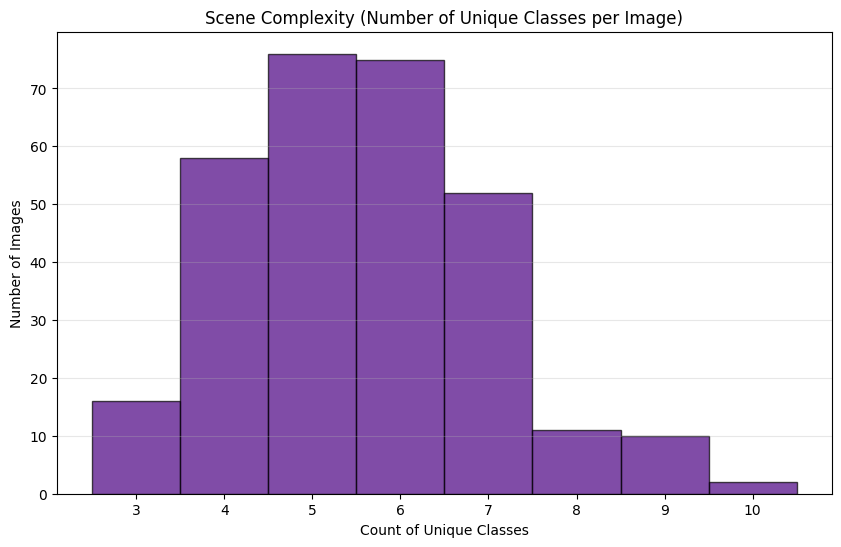

In [21]:
# Cell 14: Plot distribution of number of unique classes per training image
classes_per_image = []
for i in indices:
    mask_path = os.path.join(train_mask_folder_path, train_msks[i])
    mask_id = process_mask_to_train_id(mask_path)
    present_ids = np.unique(mask_id)
    count = len([tid for tid in present_ids if tid != 255])
    classes_per_image.append(count)
plt.figure(figsize=(10, 6))
if len(classes_per_image) > 0:
    min_val, max_val = min(classes_per_image), max(classes_per_image)
    bins = range(min_val, max_val + 2)
    xticks = range(min_val, max_val + 1)
else:
    bins, xticks = 10, []
plt.hist(classes_per_image, bins=bins, color='indigo', edgecolor='black', align='left', alpha=0.7)
plt.title('Scene Complexity (Number of Unique Classes per Image)')
plt.xlabel('Count of Unique Classes')
plt.ylabel('Number of Images')
plt.xticks(xticks)
plt.grid(axis='y', alpha=0.3)
plt.show()